## 📂 Data Import and Initial Inspection

The **Bank Marketing dataset** was successfully imported into the Jupyter Notebook environment using the **Pandas** library. The dataset was obtained from the *UCI Machine Learning Repository* and contains information related to a direct marketing campaign conducted by a Portuguese banking institution.

Each row in the dataset represents a **single customer** who was contacted during the campaign. The dataset includes:

- Demographic attributes (age, job, marital status)
- Financial information (balance, housing loan, personal loan)
- Campaign-related details (contact method, duration, number of contacts)

The target variable **`y`** indicates whether the customer subscribed to a term deposit (`yes` or `no`).

The first 10 rows were displayed to confirm that the data loaded correctly and to gain an initial understanding of the dataset structure.

In [2]:
import pandas as pd
df = pd.read_csv("../data/bank-additional-full.csv", sep=';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 📊 Dataset Dimensions
Examining the number of observations and variables to understand the size of the dataset.

In [3]:
df.shape


(41188, 21)

## 🧾 Data Structure and Types
Inspecting column names, data types, and missing values to validate the dataset structure.

In [4]:
df.info

<bound method DataFrame.info of        age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

         contact mo

## 📈 Summary Statistics
Generating descriptive statistics to understand the distribution of numerical variables.

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## 📊 Proportion of Placeholder Missing Values

Calculating the percentage of "unknown" values in each column to assess the extent of missing categorical data.

In [6]:
unknown_prop = (df == "unknown").mean()*100
unknown_prop[unknown_prop > 0].sort_values(ascending=False)

default      20.872584
education     4.202680
housing       2.403613
loan          2.403613
job           0.801204
marital       0.194231
dtype: float64

## 🧹 Handling of Placeholder Missing Values

Several categorical variables contain the value `"unknown"`, which represents missing or unavailable information.

Instead of removing these observations, the `"unknown"` category will be retained during exploratory analysis. This approach preserves the dataset size and allows investigation into whether missing information itself influences customer subscription behavior.

## 🎯 Target Variable Analysis
Evaluating the distribution of customer subscription outcomes to understand overall campaign performance.

In [7]:
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

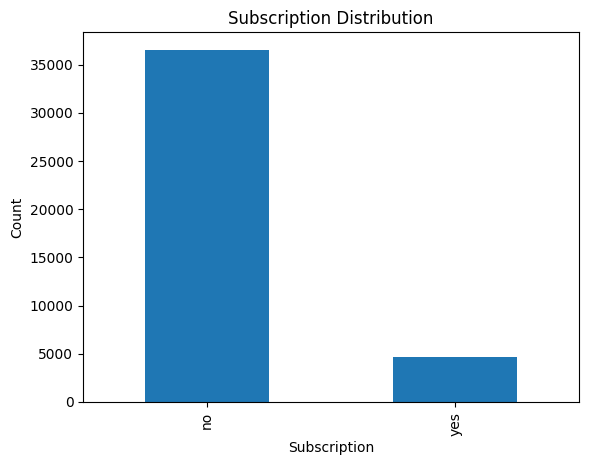

In [8]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title("Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

###  Subscription Outcome Visualization

The bar chart above illustrates the distribution of customers who subscribed to the term deposit versus those who did not.

## Call Duration vs Subscription

Analyzing whether call duration influences customer subscription behavior by comparing summary statistics and visual distributions between subscribed and non-subscribed customers.

In [9]:
# Grouped summary statistics
duration_stats = df.groupby('y')['duration'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',
    std='std'
)

duration_stats

,count,mean,median,min,max,std
y,,,,,,
no,36548,220.844807,163.5,0,4918,207.096293
yes,4640,553.191164,449.0,37,4199,401.171871


The grouped statistics above compare call duration between customers who subscribed and those who did not. 
Differences in mean and median values indicate whether longer calls are associated with higher subscription likelihood.

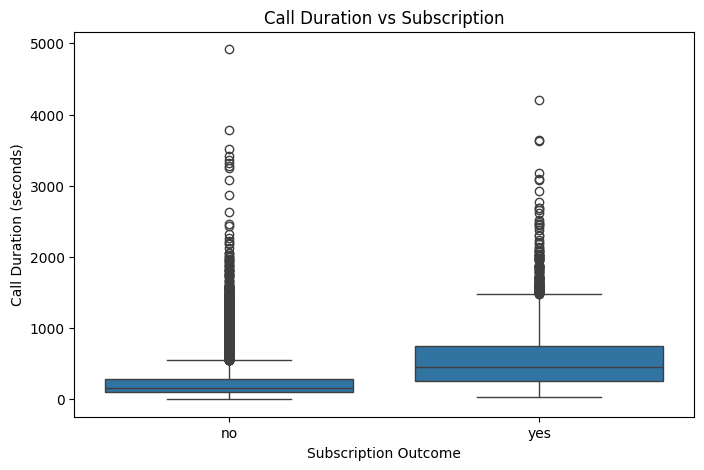

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Subscription")
plt.xlabel("Subscription Outcome")
plt.ylabel("Call Duration (seconds)")
plt.show()

### 📦 Call Duration Comparison

The boxplot compares call duration between subscribed and non-subscribed customers, highlighting differences in median and spread.

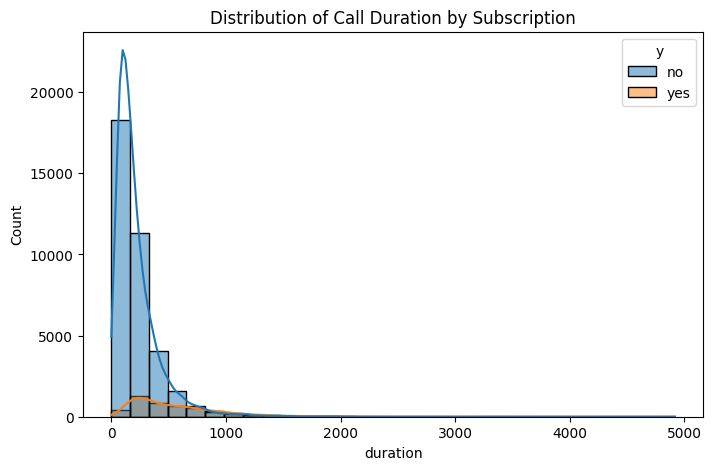

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='duration', hue='y', bins=30, kde=True)
plt.title("Distribution of Call Duration by Subscription")
plt.show()

### 📊 Call Duration Distribution

The histogram shows how call duration is distributed across subscription outcomes, helping identify differences in engagement patterns.

### 🔎 Insight

Customers who subscribed generally had longer call durations, suggesting that higher engagement increases the likelihood of subscription.

## Previous Campaign Outcome vs Subscription

Analyzing whether the outcome of a previous marketing campaign influences the likelihood of current subscription.

In [12]:
# Conversion rate by previous outcome
poutcome_table = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
poutcome_table

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


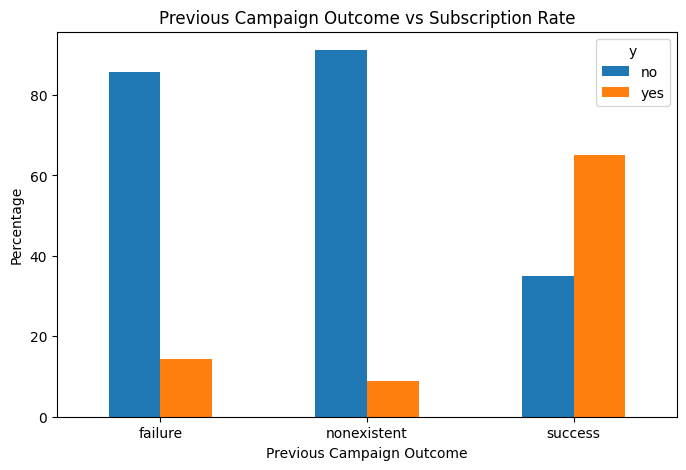

In [17]:


poutcome_table.plot(kind='bar', figsize=(8,5))
plt.title("Previous Campaign Outcome vs Subscription Rate")
plt.ylabel("Percentage")
plt.xlabel("Previous Campaign Outcome")
plt.xticks(rotation=0)
plt.show()

### 🔎 Insight

Customers who previously had a successful campaign outcome are significantly more likely to subscribe again. 
This suggests that targeting previously responsive customers could improve marketing efficiency.

## 👥 Multivariate Analysis: Age Group and Job vs Subscription

This section explores how customer age group and job category together influence the likelihood of subscribing to a term deposit. By combining these features, we can identify high-performing demographic segments.

### 🏷 Creating Age Groups

Customers are segmented into age groups to simplify demographic analysis and improve interpretability.

In [18]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '30-40', '40-50', '50-60', '60+']
)

df['age_group'].value_counts()

age_group
30-40    16385
40-50    10240
18-30     7350
50-60     6270
60+        910
Name: count, dtype: int64

### 📊 Conversion Rate by Age Group and Job

Calculating subscription rates for each combination of age group and job category.

In [19]:
age_job_conversion = pd.crosstab(
    [df['age_group'], df['job']],
    df['y'],
    normalize='index'
) * 100

age_job_conversion.sort_values(by='yes', ascending=False).head(10)

y                              no        yes
age_group job                               
60+       entrepreneur  37.500000  62.500000
          management    40.000000  60.000000
          admin.        46.808511  53.191489
          housemaid     50.000000  50.000000
          retired       53.834808  46.165192
          unknown       61.904762  38.095238
          technician    64.705882  35.294118
40-50     student       66.666667  33.333333
18-30     student       67.283073  32.716927
          unknown       72.727273  27.272727

### 📈 Top Age-Job Segments by Subscription Rate

Visualizing the highest-performing demographic segments to identify target groups.

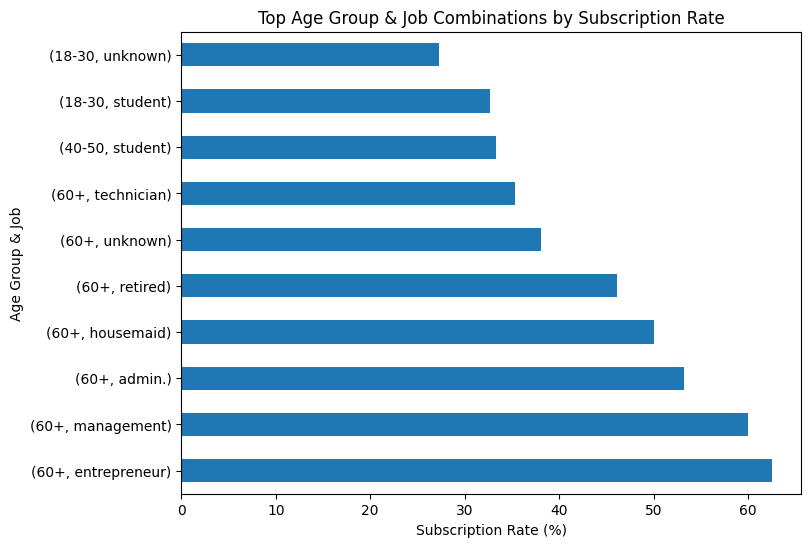

In [20]:
import matplotlib.pyplot as plt

top10 = age_job_conversion.sort_values(by='yes', ascending=False).head(10)

top10['yes'].plot(kind='barh', figsize=(8,6))
plt.title("Top Age Group & Job Combinations by Subscription Rate")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Age Group & Job")
plt.show()

### 🔎 Insight

The combined analysis of age group and job reveals specific demographic segments with significantly higher subscription rates. 

These high-performing groups represent strong candidates for targeted marketing campaigns, enabling more efficient resource allocation and improved conversion outcomes.